In [ ]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/processed/df.csv')
print('N =', len(df.prolificID.unique()))

In [7]:
#set group from df_fit 
df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')
df = df.merge(df_fit[['prolificID', 'group']], on='prolificID', how='left')

df.groupby(['expName', 'group']).prolificID.nunique()

expName        group     
FullPilot12    combined      13
               perceptual    31
               random        10
               value          7
FullPilot12_2  combined      13
               perceptual    30
               random         5
               value          7
FullPilot13    combined       5
               perceptual    22
               random        15
               value         22
FullPilot14    combined      20
               perceptual    29
               random        11
               value          5
Name: prolificID, dtype: int64

In [8]:
# print the sum of participant id for each experiment
print(df[df.group!='random'].groupby('expName').prolificID.nunique())

expName
FullPilot12      51
FullPilot12_2    50
FullPilot13      49
FullPilot14      54
Name: prolificID, dtype: int64


In [9]:
import scipy.stats as stats

session = 3
df_ = df[(df.session==session)].groupby(['prolificID'], as_index=False).mean(numeric_only=True)

df_['opti_ff'] = df_.opti_ff.astype(float)
df_['opti_ss'] = df_.opti_ss.astype(float)
df['opti_ff'] = df['opti_ff'].astype(float)
df['opti_ss'] = df['opti_ss'].astype(float)
         
df2 = df[(df.session==session)]


def get_group(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p_ss and p_ff:
        return 'combined'
        
    
    if p_ff:
        return 'perceptual'
    if p_ss:
        return 'value'

    return 'random'


df_['group'] = df_.apply(get_group, axis=1)
df['group'] = df['prolificID'].map(df_.set_index('prolificID')['group'])

print(len(df.prolificID.unique()))

245


session
0    0.662990
1    0.722631
2    0.820261
Name: opti, dtype: float64


c:\Users\basil\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\raincloudpy\raincloud.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


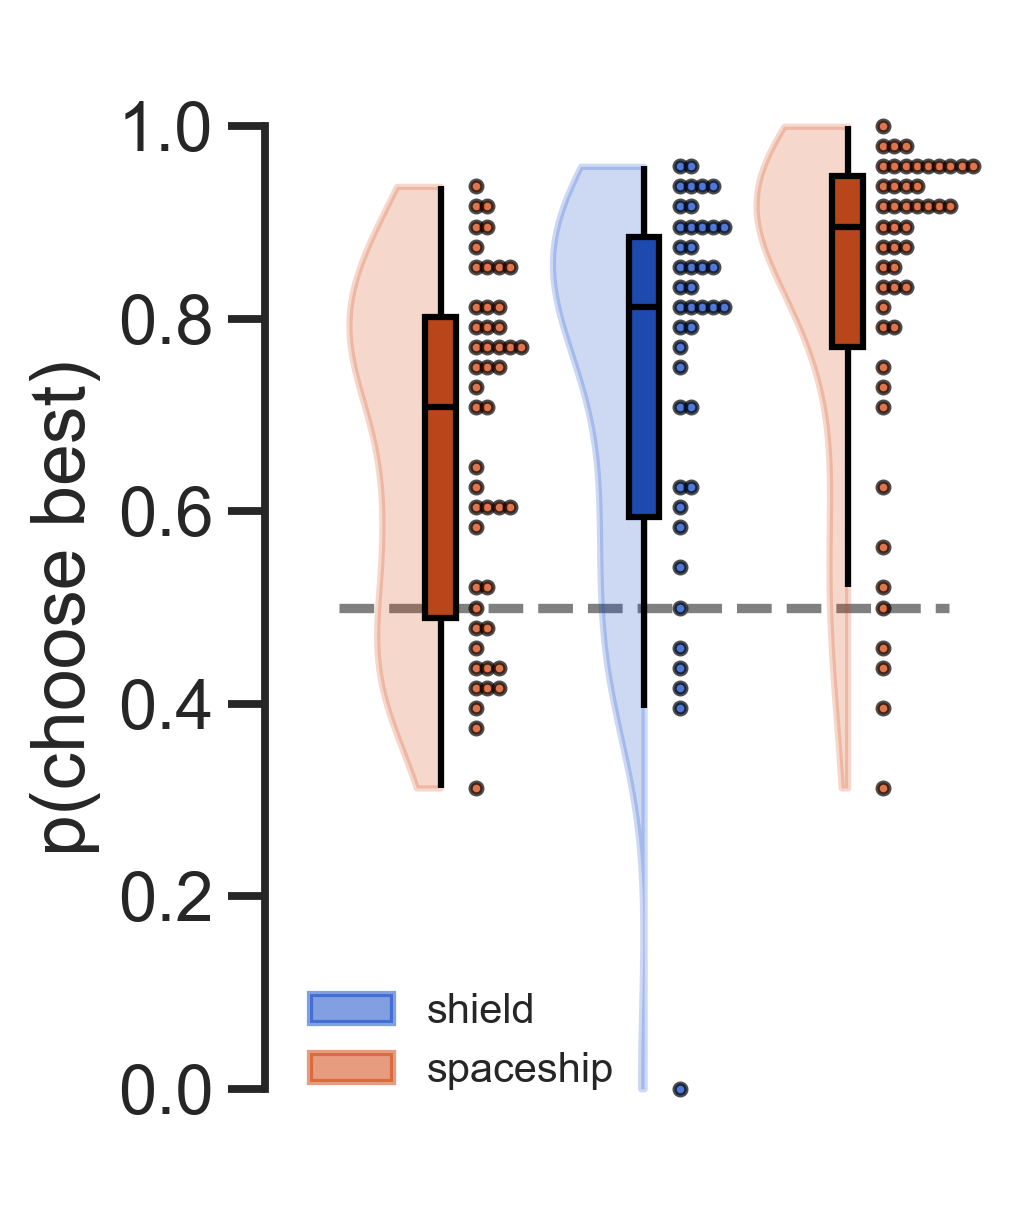

In [10]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2

sns.set(rc={'figure.figsize':(3, 5), 'figure.dpi':300})
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from raincloudpy import raincloudplot

ddf = df.copy()

ddf = ddf[ddf.session.isin([0,1, 2])]
ddf = ddf[ddf.expName.isin(['FullPilot12'])  & (ddf.group!='random')]

# create a new dataframe with id, opti_ss, opti_ff, session
ddf.loc[ddf.session.isin([0,2]), 'opti'] = ddf[ddf.session.isin([0,2])].opti_ss
# ddf.loc[ddf.session.isin([0,2]), 'session'] = 2
ddf.loc[ddf.session == 1, 'opti'] = ddf[ddf.session == 1].opti_ff
ddf['opti'] = ddf.opti.astype(float)

ddf = ddf.groupby(['prolificID', 'session'], as_index=False).opti.mean()

print(ddf.groupby('session').opti.mean())
model = pd.read_csv('df_sim.csv')
model = model[(model.session.isin([0,1,2]))]
model.loc[model.session.isin([0,2]), 'opti'] = model[model.session.isin([0,2])].opti_ss
# model.loc[model.session.isin([0,2]), 'session'] = 2
model.loc[model.session == 1, 'opti'] = model[model.session == 1].opti_ff
normative_means = model.groupby(['session'], as_index=False).opti.mean()
C0, C1, C2 = ('#2a8669', '#d23a00', '#0641c7')

from raincloudpy import raincloudplot
raincloudplot(
    x='session', y='opti', data=ddf, 
    palette=[C1, C2, C1], dot_size=8, dot_spacing=0.055,
    box_kwargs={'color':'black', 'linecolor': 'black', 'linewidth':1.5},
    box_dots_spacing=0.1, y_threshold=0.01, violin_width=0.45,
)

plt.plot([-.5, 2.5], [0.5, 0.5], color='grey', linestyle='--', zorder=-100)
sns.despine(trim=True, bottom=True, offset=10)
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.ylabel('p(choose best)')
plt.xticks([])
plt.ylim(-.1, 1.1)
plt.tick_params(axis='x', which='both', length=0)

# orange is "spaceship training"
# blue is "shield training"

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

handles = [
    mpatches.Patch(color=C2, label='shield', alpha=0.5),
    mpatches.Patch(color=C1, label='spaceship', alpha=0.5),
    

]

plt.legend(title='', handles=handles, loc='lower left', fontsize=10, bbox_to_anchor=(-0.05, 0.05), frameon=False)

In [11]:
import pingouin as pg

# ddf.loc[ddf.session==2, 'session'] = 0
print(pg.pairwise_tests(ddf, dv='opti', within='session', padjust='bonf', parametric=True, effsize='cohen', subject='prolificID').loc[2])




Contrast         session
A                      1
B                      2
Paired              True
Parametric          True
T              -2.715762
dof                 50.0
alternative    two-sided
p-unc           0.009055
p-corr          0.027165
p-adjust            bonf
BF10               4.062
cohen          -0.510316
Name: 2, dtype: object


In [12]:
# normative means comparison 
import scipy.stats as stats
stats.ttest_1samp(ddf[ddf.session==2].opti, .99)

TtestResult(statistic=np.float64(-6.834432388655256), pvalue=np.float64(1.089693180433423e-08), df=np.int64(50))

session
0    0.662990
1    0.722631
2    0.820261
3         NaN
4         NaN
Name: opti, dtype: float64


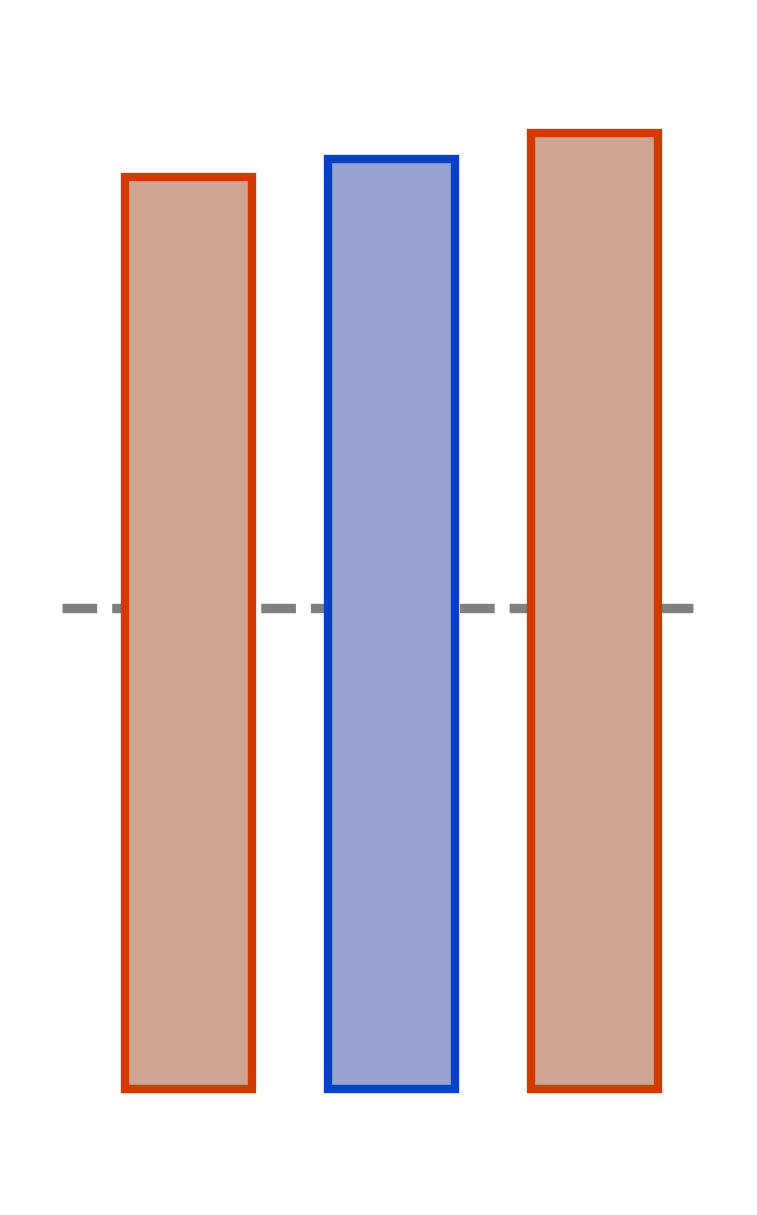

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

ddf = df.copy()

dddf = ddf[ddf.session.isin([0,1, 2])]
ddf = ddf[ddf.expName.isin(['FullPilot12'])  & (ddf.group!='random')]

# create a new dataframe with id, opti_ss, opti_ff, session
ddf.loc[ddf.session.isin([0,2]), 'opti'] = ddf[ddf.session.isin([0,2])].opti_ss
# ddf.loc[ddf.session.isin([0,2]), 'session'] = 2
ddf.loc[ddf.session == 1, 'opti'] = ddf[ddf.session == 1].opti_ff
ddf['opti'] = ddf.opti.astype(float)

ddf = ddf.groupby(['prolificID', 'session'], as_index=False).opti.mean()

print(ddf.groupby('session').opti.mean())
model = pd.read_csv('df_sim.csv')
model = model[(model.session.isin([0,1,2]))]
model.loc[model.session.isin([0,2]), 'opti'] = model[model.session.isin([0,2])].opti_ss
# model.loc[model.session.isin([0,2]), 'session'] = 2
model.loc[model.session == 1, 'opti'] = model[model.session == 1].opti_ff
normative_means = model.groupby(['session'], as_index=False).opti.mean()

order = ['ff', 'ss']
C0, C1_, C2_ = ('#2a8669', '#d23a00', '#0641c7')
C1 = '#cda590'
C2 = '#97a3d1'
plt.figure(figsize=(3, 5), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from raincloudpy import raincloudplot
plt.plot([-0.5, 2], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)

#
bar_data = pd.DataFrame({
    'x': [0, 1, 2],
    'y': normative_means.values[:,1],
    'category': ['spaceship', 'shield', 'spaceship ']
})

# Use manual bar positioning with plt.bar for precise control
bar_width = 0.5
bar_positions = [0, 0.8, 1.6]  # Adjust this value to control spacing (smaller = closer together)

ax = plt.bar(bar_positions,bar_data.y, width=bar_width,
        color=[C1, C2, C1], alpha=1, edgecolor=[C1_, C2_, C1_], 
        linewidth=2, zorder=10)

plt.ylabel('p(choose best)')
# Manually set edge colors with full opacity
for i, bar in enumerate(ax.patches):
    edge_color = [C1_, C2_, C1_][i]
    bar.set_edgecolor(edge_color)
    bar.set_linewidth(2)
plt.ylabel('p(choose best)')
# sns.despine(trim=True, bottom=True)
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.ylim(-.1, 1.1)
sns.despine(trim=True, bottom=True, left=True)

# remove y axis line, ticks, and labels (plt)
plt.gca().yaxis.set_ticks_position('none')
plt.gca().yaxis.set_ticklabels([])
plt.gca().spines['left'].set_visible(False)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

handles = [
    mpatches.Patch(color=C2, label='shield', alpha=0.5),

    mpatches.Patch(color=C1, label='spaceship', alpha=0.5),
   
]


In [14]:
normative_means.values[:,1]

array([0.9474768280123584, 0.9657885733835101, 0.9934819897084048],
      dtype=object)

In [15]:
import pingouin as pg
ddf['opti'] = ddf['opti'].astype(float)  # Convert boolean to numeric (True->1.0, False->0.0)

pg.pairwise_tests(data=ddf, dv='opti', between='session', parametric=True, padjust='bonf')

AssertionError: y cannot be an empty list or array.

var
ev    0.712380
ff    0.746922
ss    0.567145
Name: opti, dtype: float64


c:\Users\basil\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\raincloudpy\raincloud.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


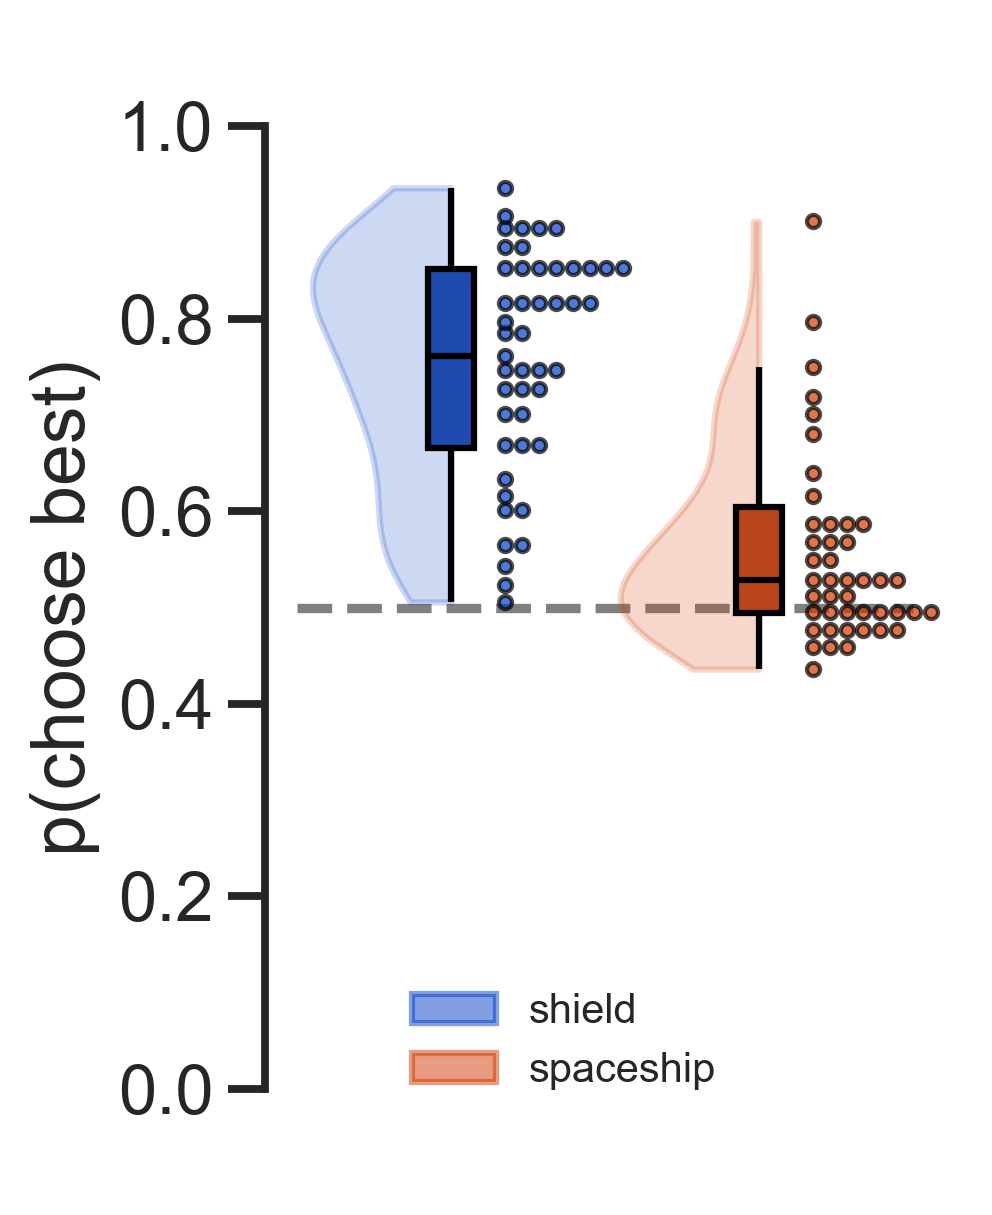

In [ ]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2
import matplotlib.pyplot as plt
import seaborn as sns


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
ddf = ddf[ddf.session.isin([3])]
ddf = ddf[ddf.expName.isin(['FullPilot12']) & (ddf.group!='random')]

# create a column named var that is either ss, ff, or ev
# the column value is named by opti
# Melt the dataframe to create 'var' and 'opti' columns
df_melted = ddf.melt(
    id_vars=[col for col in ddf.columns if col not in ['opti_ss', 'opti_ff', 'opti_ev']], 
    value_vars=['opti_ss', 'opti_ff', 'opti_ev'],
    var_name='var', 
    value_name='opti'
)

# Clean up the 'var' column to remove 'opti_' prefix
df_melted['var'] = df_melted['var'].str.replace('opti_', '')

# If you want to replace the original df:
# df = df_melted
model = pd.read_csv('df_sim.csv')
model = model[(model.session==3) & (model.pair.isin([0,1]))]
# melt model as with df_melted
model_melted = model.melt(
    id_vars=[col for col in model.columns if col not in ['opti_ss', 'opti_ff', 'opti_ev']], 
    value_vars=['opti_ss', 'opti_ff', 'opti_ev'],  
    var_name='var', 
    value_name='opti')
# get the means for each var
var_means_normative = model_melted.groupby('var').opti.mean()
# select only ev
# var_means_normative = var_means_normative[var_means_normative.index!='opti_ev']
ddf = df_melted.groupby(['prolificID', 'session', 'var'], as_index=False).opti.mean().astype({'opti': float})
# drop where var is not 'ev'
# ddf = ddf.query("var != 'ev'")
print(ddf.groupby('var').opti.mean())
order = ['ss', 'ff', 'ev']
order = ['ff', 'ss']
C0, C1, C2 = ('#2a8669', '#d23a00', '#0641c7')
plt.figure(figsize=(3, 5), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from raincloudpy import raincloudplot
plt.plot([-0.5, 1.5], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)

raincloudplot(
    x='var', y='opti', data=ddf[ddf.session==3], 
    palette=[C2, C1], dot_size=10, dot_spacing=0.055,
    box_kwargs={'color':'black', 'linecolor': 'black', 'linewidth':1.5},
    box_dots_spacing=0.1, y_threshold=0.015, violin_width=0.45,order=order
)



# plt.scatter(x=[-.25, 0.75], y=var_means_normative.values,
#              color='black', s=100, marker='D', label='normative model', zorder=10, edgecolor='white', linewidth=1)

# plt.bar(x=[2, 3], height=var_means_normative.values, color='black', alpha=0.7, zorder=10, label='normative model', edgecolor='white')
plt.ylabel('p(choose best)')
# sns.despine(trim=True, bottom=True)
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.xticks([])
plt.ylim(-.1, 1.1)
sns.despine(trim=True, bottom=True)
# orange is "spaceship training"
# blue is "shield training"
# import patch
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

handles = [
    mpatches.Patch(color=C2, label='shield', alpha=0.5),

    mpatches.Patch(color=C1, label='spaceship', alpha=0.5),
    # mpatches.Patch(color='C0', label='participants', alpha=0.5),
    # Use Line2D for the diamond marker
#     mlines.Line2D([0], [0], marker='D', color='w', label='normative model', 
#            markerfacecolor='black', markeredgecolor='white', 
#            markersize=10, markeredgewidth=1)
]
plt.legend(title='', handles=handles, loc='lower right', frameon=False, fontsize=10, bbox_to_anchor=(0.7, 0.05))

var
ff    0.746922
ss    0.567145
Name: opti, dtype: float64


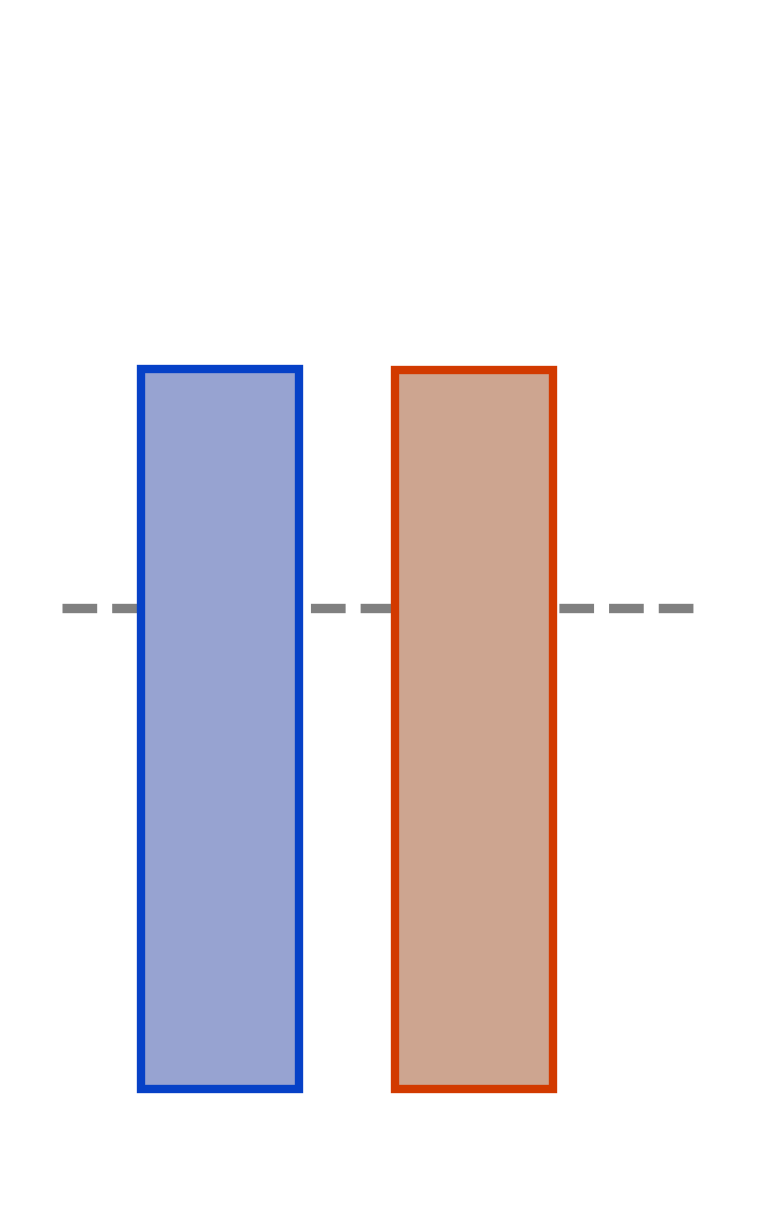

In [ ]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2
import matplotlib.pyplot as plt
import seaborn as sns


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
ddf = ddf[ddf.session.isin([3])]
ddf = ddf[ddf.expName.isin(['FullPilot12']) & (ddf.group!='random')]

# create a column named var that is either ss, ff, or ev
# the column value is named by opti
# Melt the dataframe to create 'var' and 'opti' columns
df_melted = ddf.melt(
    id_vars=[col for col in ddf.columns if col not in ['opti_ss', 'opti_ff', 'opti_ev']], 
    value_vars=['opti_ss', 'opti_ff', 'opti_ev'],
    var_name='var', 
    value_name='opti'
)

# Clean up the 'var' column to remove 'opti_' prefix
df_melted['var'] = df_melted['var'].str.replace('opti_', '')

# If you want to replace the original df:
# df = df_melted
model = pd.read_csv('df_sim.csv')
model = model[(model.session==3) & (model.pair.isin([0,1]))]
# melt model as with df_melted
model_melted = model.melt(
    id_vars=[col for col in model.columns if col not in ['opti_ss', 'opti_ff', 'opti_ev']], 
    value_vars=['opti_ss', 'opti_ff', 'opti_ev'],  
    var_name='var', 
    value_name='opti')
# get the means for each var
var_means_normative = model_melted.groupby('var').opti.mean()
# select only ev
var_means_normative = var_means_normative[var_means_normative.index!='opti_ev']
ddf = df_melted.groupby(['prolificID', 'session', 'var'], as_index=False).opti.mean().astype({'opti': float})
# drop where var is not 'ev'
ddf = ddf.query("var != 'ev'")
print(ddf.groupby('var').opti.mean())
order = ['ss', 'ff', 'ev']
order = ['ff', 'ss']
C0, C1_, C2_ = ('#2a8669', '#d23a00', '#0641c7')
C1 = '#cda590'
C2 = '#97a3d1'
plt.figure(figsize=(3, 5), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from raincloudpy import raincloudplot
plt.plot([-0.5, 1.5], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)

# plt.scatter(x=[-.25, 0.75], y=var_means_normative.values,
#              color='black', s=100, marker='D', label='normative model', zorder=10, edgecolor='white', linewidth=1)
bar_data = pd.DataFrame({
    'x': [0, 1],
    'y': var_means_normative.values,
    'category': ['shield', 'spaceship']
})
# ax = sns.barplot(data=bar_data, x='x', y='y', hue='category', 
#             palette=[C2, C1], alpha=1, edgecolor=[C2_, C1_],  zorder=10, width=0.5,
#             linewidth=2, legend=False, gap=0.01)
# plt.bar(x=[0, 1], height=var_means_normative.values, facecolor=[C2, C1], alpha=0.5, zorder=10, label='normative model', linewidth=2, edgecolor=[C2, C1])

# Use manual bar positioning with plt.bar for precise control
bar_width = 0.5
bar_positions = [0, 0.8]  # Adjust this value to control spacing (smaller = closer together)

ax = plt.bar(bar_positions, var_means_normative.values, width=bar_width,
        color=[C2, C1], alpha=1, edgecolor=[C2_, C1_], 
        linewidth=2, zorder=10)

# plt.scatter(x=bar_positions, y=var_means_normative.values,
#              color=[C2_, C1_], s=100, marker='D', zorder=10, edgecolor='white', linewidth=1)
plt.ylabel('p(choose best)')
# Manually set edge colors with full opacity
for i, bar in enumerate(ax.patches):
    edge_color = C2_ if i == 0 else C1_
    bar.set_edgecolor(edge_color)
    bar.set_linewidth(2)
# plt.bar(x=[0, 1], height=var_means_normative.values, facecolor=[C2, C1], alpha=0.5, zorder=10, label='normative model', linewidth=2, edgecolor=[C2, C1])
plt.ylabel('p(choose best)')
# sns.despine(trim=True, bottom=True)
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.ylim(-.1, 1.1)
sns.despine(trim=True, bottom=True, left=True)
# remove y axis line, ticks, and labels (sns)

# ax.yaxis.set_ticks_position('none')
# ax.yaxis.set_ticklabels([])
# ax.spines['left'].set_visible(False)
# remove y axis line, ticks, and labels (plt)
plt.gca().yaxis.set_ticks_position('none')
plt.gca().yaxis.set_ticklabels([])
plt.gca().spines['left'].set_visible(False)
# set tick
# orange is "spaceship training"
# blue is "shield training"
# import patch
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

handles = [
    mpatches.Patch(color=C2, label='shield', alpha=0.5),

    mpatches.Patch(color=C1, label='spaceship', alpha=0.5),
    # mpatches.Patch(color='C0', label='participants', alpha=0.5),
    # Use Line2D for the diamond marker
    # mlines.Line2D([0], [0], marker='D', color='w', label='normative model', 
    #        markerfacecolor='black', markeredgecolor='white', 
    #        markersize=10, markeredgewidth=1)
]
# plt.legend(title='', handles=handles, loc='lower right', frameon=False, fontsize=10, bbox_to_anchor=(0.7, 0.05))

var
ev    0.704699
Name: opti, dtype: float64


c:\Users\garciaba\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\raincloudpy\raincloud.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


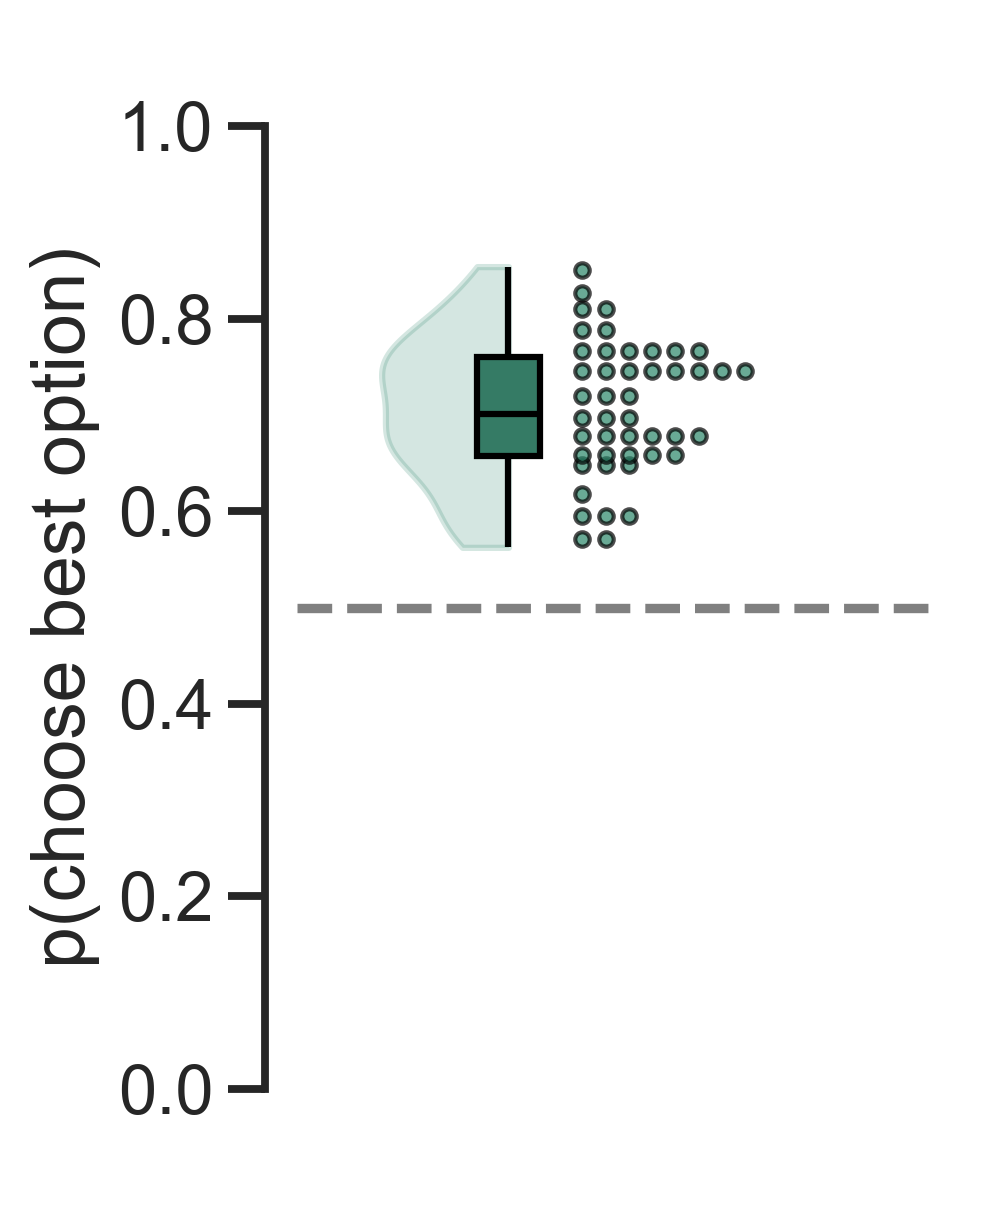

In [ ]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
ddf = ddf[ddf.session.isin([3])]
ddf = ddf[ddf.expName.isin(['FullPilot12']) & (ddf.group!='random') & (ddf.pair.isin([0,1]))]

# create a column named var that is either ss, ff, or ev
# the column value is named by opti
# Melt the dataframe to create 'var' and 'opti' columns
df_melted = ddf.melt(
    id_vars=[col for col in ddf.columns if col not in ['opti_ss', 'opti_ff', 'opti_ev']], 
    value_vars=['opti_ss', 'opti_ff', 'opti_ev'],
    var_name='var', 
    value_name='opti'
)

# Clean up the 'var' column to remove 'opti_' prefix
df_melted['var'] = df_melted['var'].str.replace('opti_', '')


ddf = df_melted.groupby(['prolificID', 'session', 'var'], as_index=False).opti.mean().astype({'opti': float})
# drop where var is not 'ev'
ddf = ddf.query("var == 'ev'")
print(ddf.groupby('var').opti.mean())
order = ['ss', 'ff', 'ev']
order = ['ev']

plt.figure(figsize=(3, 5), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from raincloudpy import raincloudplot
plt.plot([-0.5, 1], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)
C0, C1, C2 = ('#2a8669', '#d23a00', '#0641c7')

raincloudplot(
    x='var', y='opti', data=ddf[ddf.session==3], 
    palette=[C0], dot_size=12, dot_spacing=0.055, box_width=0.15, 
    box_kwargs={'color':'black', 'linecolor': 'black', 'linewidth':1.5},
    box_dots_spacing=0.1, y_threshold=0.015, violin_width=0.3,
)

#plt.scatter(x=[0], y=var_means_normative.values,
#             color='black', s=100, marker='D', label='normative model', zorder=10, edgecolor='white', linewidth=1)
plt.ylabel('p(choose best option)')
# sns.despine(trim=True, bottom=True)
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.xticks([])
plt.ylim(-.1, 1.1)
sns.despine(trim=True, bottom=True)
# orange is "spaceship training"
# blue is "shield training"
# import patch
# import matplotlib.patches as mpatches
# import matplotlib.lines as mlines

# handles = [
#     # mpatches.Patch(color='C2', label='shield', alpha=0.5),

#     # mpatches.Patch(color='C1', label='spaceship', alpha=0.5),
#     #mpatches.Patch(color=C0, label='participants', alpha=0.5),
#     # Use Line2D for the diamond marker
#     # mlines.Line2D([0], [0], marker='D', color='w', label='normative model', 
#     #        markerfacecolor='black', markeredgecolor='white', 
#     #        markersize=10, markeredgewidth=1)
# ]
# plt.legend(title='', handles=handles, loc='lower right', frameon=False, fontsize=10, bbox_to_anchor=(0.7, 0.05))

session
0    0.662990
1    0.722631
2    0.820261
3         NaN
4         NaN
Name: opti, dtype: float64


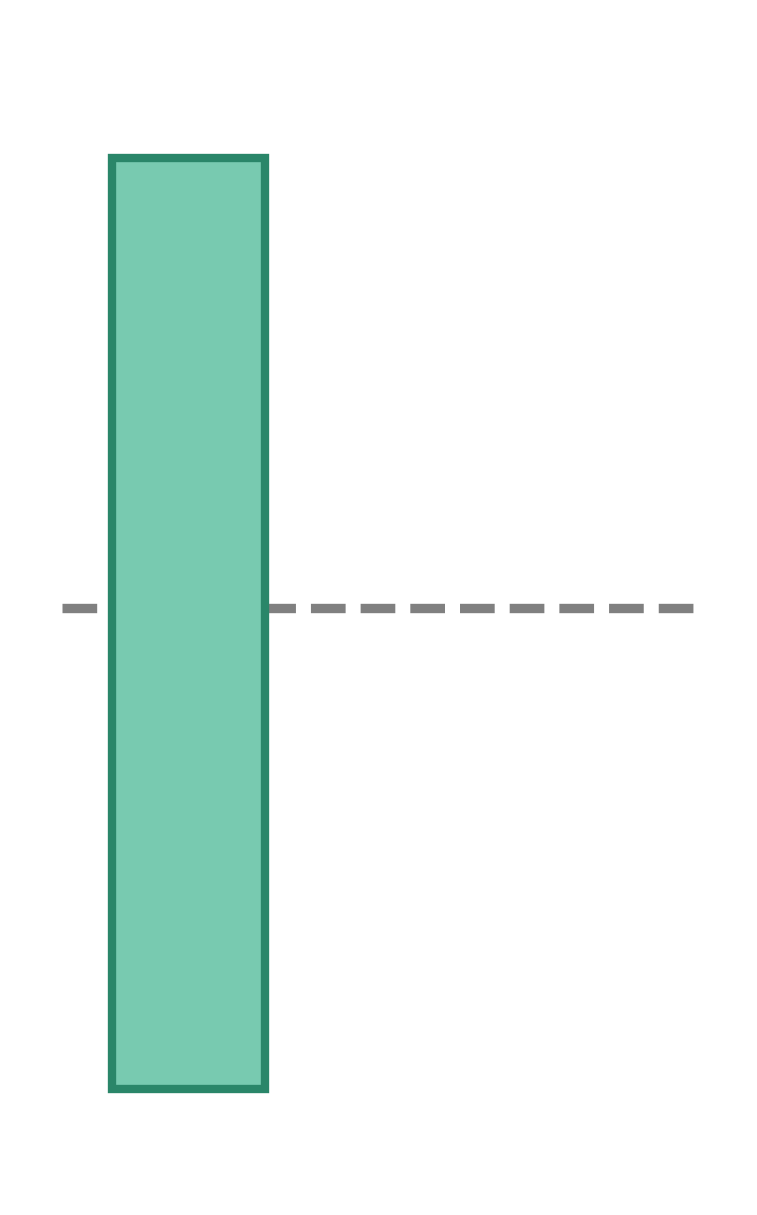

In [ ]:
# compare opti_ss mean in session 2 to opti_ff_mean in session 2
import matplotlib.pyplot as plt
import seaborn as sns


ddf = df.copy()
# ddf = ddf[ddf.group!='random']
# ddf = ddf[ddf.t>23] 
dddf = ddf[ddf.session.isin([0,1, 2])]
ddf = ddf[ddf.expName.isin(['FullPilot12'])  & (ddf.group!='random')]
# ddf = ddf[ddf.group!='random']

# create a new dataframe with id, opti_ss, opti_ff, session
ddf.loc[ddf.session.isin([0,2]), 'opti'] = ddf[ddf.session.isin([0,2])].opti_ss
# ddf.loc[ddf.session.isin([0,2]), 'session'] = 2
ddf.loc[ddf.session == 1, 'opti'] = ddf[ddf.session == 1].opti_ff
ddf['opti'] = ddf.opti.astype(float)

ddf = ddf.groupby(['prolificID', 'session'], as_index=False).opti.mean()

print(ddf.groupby('session').opti.mean())
model = pd.read_csv('df_sim.csv')
model = model[(model.session.isin([0,1,2]))]
model.loc[model.session.isin([0,2]), 'opti'] = model[model.session.isin([0,2])].opti_ss
# model.loc[model.session.isin([0,2]), 'session'] = 2
model.loc[model.session == 1, 'opti'] = model[model.session == 1].opti_ff
normative_means = model.groupby(['session'], as_index=False).opti.mean()

order = ['ff', 'ss']
C0, C1_, C2_ = ('#2a8669', '#d23a00', '#0641c7')
C1 = '#cda590'
C2 = '#97a3d1'
plt.figure(figsize=(3, 5), dpi=300)
sns.set_style('ticks')
sns.set_context('talk')
sns.set_palette('Set2')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from raincloudpy import raincloudplot
plt.plot([-0.5, 2], [0.5, 0.5], color='grey', linestyle='--', zorder=-1000)

model = pd.read_csv('df_sim.csv')
model = model[(model.session==3) & (model.pair.isin([0,1]))]
# melt model as with df_melted
model_melted = model.melt(
    id_vars=[col for col in model.columns if col not in ['opti_ss', 'opti_ff', 'opti_ev']], 
    value_vars=['opti_ss', 'opti_ff', 'opti_ev'],  
    var_name='var', 
    value_name='opti')
# get the means for each var
var_means_normative = model_melted.groupby('var').opti.mean()
# select only ev
var_means_normative = var_means_normative[var_means_normative.index=='opti_ev']
bar_data = pd.DataFrame({
    'x': [0],
    'y': var_means_normative.values,
})

C0_ = '#2a8669'
C0 = "#78cab083"

# Use manual bar positioning with plt.bar for precise control
bar_width = 0.6

bar_positions = [0]  # Adjust this value to control spacing (smaller = closer together)

ax = plt.bar(bar_positions,bar_data.y, width=bar_width,
        color=[C0], alpha=1, edgecolor=[C0_], 
        linewidth=2, zorder=10)

# plt.scatter(x=bar_positions, y=var_means_normative.values,
#              color=[C2_, C1_], s=100, marker='D', zorder=10, edgecolor='white', linewidth=1)
plt.ylabel('p(choose best)')
# Manually set edge colors with full opacity
for i, bar in enumerate(ax.patches):
    bar.set_edgecolor(C0_)
    bar.set_linewidth(2)
plt.ylabel('p(choose best)')
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.ylim(-.1, 1.1)
sns.despine(trim=True, bottom=True, left=True)

plt.gca().yaxis.set_ticks_position('none')
plt.gca().yaxis.set_ticklabels([])
plt.gca().spines['left'].set_visible(False)



In [ ]:
var_means_normative
ddf.groupby(['session', 'var']).opti.mean()


session  var
3        ev     0.712380
         ff     0.746922
         ss     0.567145
Name: opti, dtype: float64

In [ ]:
import pingouin as pg

print(pg.pairwise_tests(
    within='var', dv='opti', data=ddf[ddf.session==3], 
    padjust='bonferroni', parametric=True, effsize='cohen', subject='prolificID', ))

print(pg.ttest(
    x=ddf[(ddf.session==3) & (ddf['var'].str.contains('ff'))].opti.values,
    y=ddf[(ddf.session==3) & (ddf['var'].str.contains('ss'))].opti.values,
    paired=True, confidence=0.95
))

  Contrast   A   B  Paired  Parametric        T   dof alternative  \
0      var  ff  ss    True        True  6.89069  50.0   two-sided   

          p-unc       BF10    cohen  
0  8.897361e-09  1.402e+06  1.61777  
              T  dof alternative         p-val         CI95%  cohen-d  \
T-test  6.89069   50   two-sided  8.897361e-09  [0.13, 0.23]  1.61777   

             BF10  power  
T-test  1.402e+06    1.0  


compare with norm ev

In [ ]:
print(pg.ttest(
ddf[ddf['var']=='ev'].opti.values,
    var_means_normative.opti_ev, confidence=0.95, correction='bonferroni')
)
print(pg.ttest(
ddf[ddf['var']=='ev'].opti.values,
    .5, confidence=0.95, correction='bonferroni')
)

                T  dof alternative         p-val         CI95%  cohen-d  \
T-test -23.890791   50   two-sided  5.233280e-29  [0.69, 0.73]  3.34538   

             BF10  power  
T-test  5.439e+25    1.0  
                T  dof alternative         p-val         CI95%   cohen-d  \
T-test  19.922957   50   two-sided  1.965185e-25  [0.69, 0.73]  2.789772   

             BF10  power  
T-test  1.765e+22    1.0  


In [ ]:
print(stats.ttest_1samp(
    ddf[(ddf.session==3) & (ddf['var'].str.contains('ss'))].opti.values,
    var_means_normative.loc['opti_ss'],
))

# same but with pingouin
print(pg.ttest(
    ddf[(ddf.session==3) & (ddf['var'].str.contains('ss'))].opti.values,
    var_means_normative.loc['opti_ss'],
    paired=False,
    confidence=0.95,
))

TtestResult(statistic=-12.78645767252341, pvalue=2.2148294613708668e-17, df=50)
                T  dof alternative         p-val        CI95%   cohen-d  \
T-test -12.786458   50   two-sided  2.214829e-17  [0.54, 0.6]  1.790462   

             BF10  power  
T-test  2.604e+14    1.0  


In [ ]:
import pingouin as pg
ddf['opti'] = ddf['opti'].astype(float)  # Convert boolean to numeric (True->1.0, False->0.0)

# pg.pairwise_tests(data=ddf, dv='opti', between='var', parametric=True, padjust='bonf')
import pingouin as pg

# For within-subjects pairwise tests
pg.pairwise_tests(data=ddf, dv='opti', within='var', subject='prolificID', 
                  parametric=True, padjust='bonf').round(6)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,var,ev,ff,True,True,-1.981788,60.0,two-sided,0.05209,0.156269,bonf,0.87,-0.152348
1,var,ev,ss,True,True,8.027924,60.0,two-sided,0.00000,0.000000,bonf,2.185e+08,1.059964
2,var,ff,ss,True,True,5.689344,60.0,two-sided,0.00000,0.000001,bonf,3.693e+04,1.012818
